In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pip install yfinance


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\johan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import yfinance as yf
from datetime import datetime

# Define el ticker de IBM
ticker = "IBM"

# Define la fecha de inicio (el inicio de los datos disponibles)
start_date = datetime(1962, 1, 1)  # Yahoo Finance usualmente tiene datos desde mucho antes

# Define la fecha de fin (hoy)
end_date = datetime.now()

# Descarga los datos históricos
data = yf.download(ticker, start=start_date, end=end_date)

# Imprime el DataFrame con los datos históricos
print(data)



YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open   Volume
Ticker             IBM         IBM         IBM         IBM      IBM
Date                                                               
1962-01-02    1.491551    1.508501    1.491551    1.508501   407940
1962-01-03    1.504588    1.504588    1.491550    1.491550   305955
1962-01-04    1.489594    1.504588    1.488943    1.504588   274575
1962-01-05    1.460260    1.487640    1.457652    1.487640   384405
1962-01-08    1.432879    1.458955    1.421145    1.458955   572685
...                ...         ...         ...         ...      ...
2025-04-11  235.479996  237.580002  227.509995  229.720001  4325900
2025-04-14  239.059998  241.770004  236.729996  239.770004  3321500
2025-04-15  240.699997  241.529999  238.270004  239.550003  3363700
2025-04-16  238.570007  243.300003  235.889999  240.279999  4869900
2025-04-17  238.809998  241.779999  237.399994  239.679993  4626900

[15931 rows x 5 columns]


In [7]:
data.to_csv('IBM.csv', index="Date")


In [13]:
ibm = pd.read_csv("IBM.csv")
ibm.head()

# employees['Start Date'] = pd.to_datetime(employees['Start Date'], format="%m/%d/%Y")




,Date,Close,High,Low,Open,Volume
0,02/01/1962,1.491551,1.508500,1.491551,1.508500,407940
1,03/01/1962,1.504589,1.504589,1.491551,1.491551,305955
2,04/01/1962,1.489595,1.504589,1.488944,1.504589,274575
3,05/01/1962,1.460259,1.487639,1.457652,1.487639,384405
4,08/01/1962,1.432879,1.458955,1.421145,1.458955,572685


In [ ]:
ibm['Date'] = pd.to_datetime(ibm['Date'], format='mixed')
print(ibm['Date'].head())

0   1962-02-01
1   1962-03-01
2   1962-04-01
3   1962-05-01
4   1962-08-01
Name: Date, dtype: datetime64[ns]


In [ ]:
# bond = bond.reset_index().set_index("Year")
ibm = ibm.reset_index().set_index("Date")

ibm.head()

,index,Close,High,Low,Open,Volume
Date,,,,,,
1962-02-01,0,1.491551,1.508500,1.491551,1.508500,407940
1962-03-01,1,1.504589,1.504589,1.491551,1.491551,305955
1962-04-01,2,1.489595,1.504589,1.488944,1.504589,274575
1962-05-01,3,1.460259,1.487639,1.457652,1.487639,384405
1962-08-01,4,1.432879,1.458955,1.421145,1.458955,572685


In [25]:
del ibm ["index"]

In [26]:
ibm.head()

,Close,High,Low,Open,Volume
Date,,,,,
1962-02-01,1.491551,1.508500,1.491551,1.508500,407940
1962-03-01,1.504589,1.504589,1.491551,1.491551,305955
1962-04-01,1.489595,1.504589,1.488944,1.504589,274575
1962-05-01,1.460259,1.487639,1.457652,1.487639,384405
1962-08-01,1.432879,1.458955,1.421145,1.458955,572685


<Axes: xlabel='Date'>

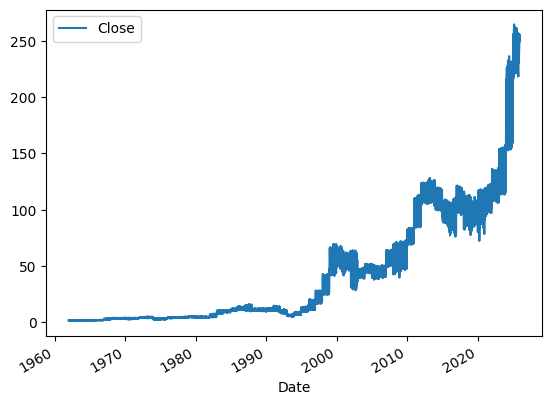

In [27]:
ibm.plot(y="Close")

<Axes: xlabel='Date'>

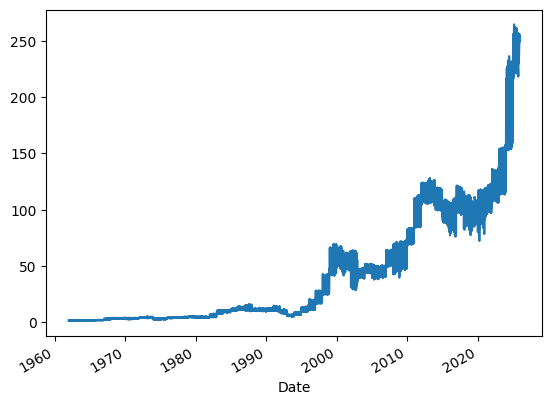

In [28]:
ibm["Close"].plot()

<Axes: xlabel='Date'>

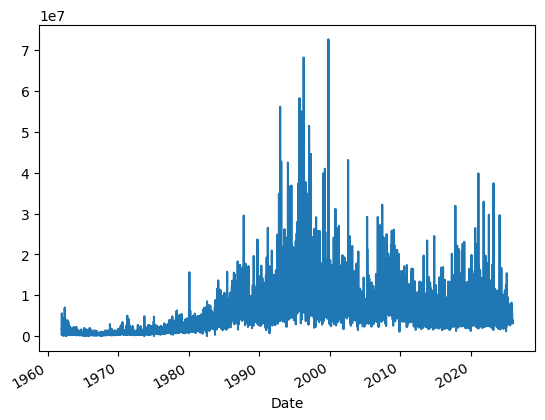

In [29]:
ibm["Volume"].plot()

In [30]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

<Axes: xlabel='Date'>

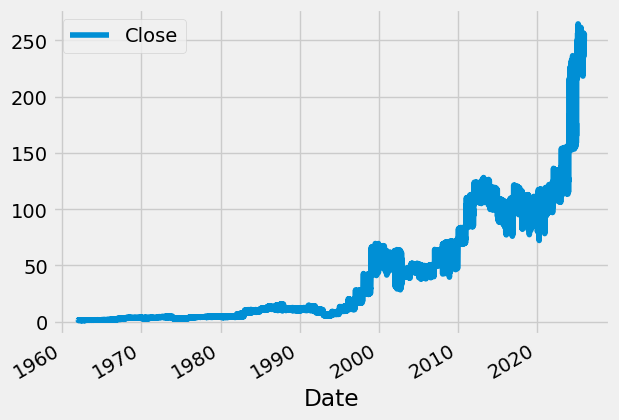

In [32]:
plt.style.use("fivethirtyeight")
ibm.plot(y="Close")

<Axes: xlabel='Date'>

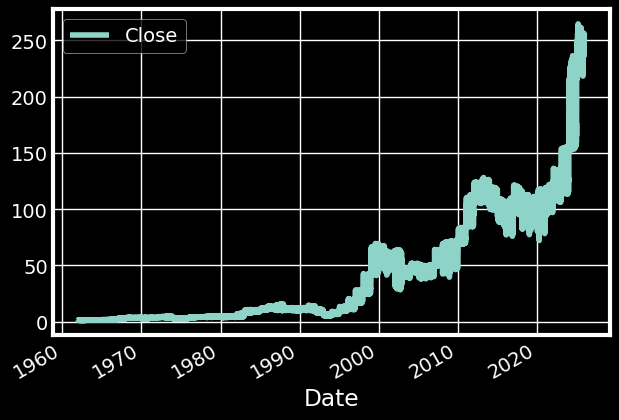

In [34]:
plt.style.use("dark_background")
ibm.plot(y="Close")

<Axes: xlabel='Date'>

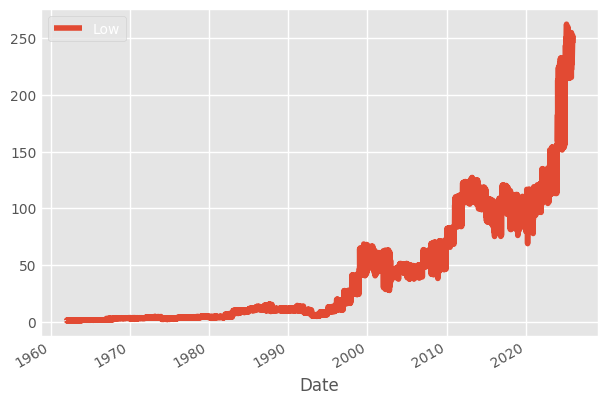

In [ ]:
plt.style.use("ggplot")
ibm.plot(y="Low")

<Axes: ylabel='Close'>

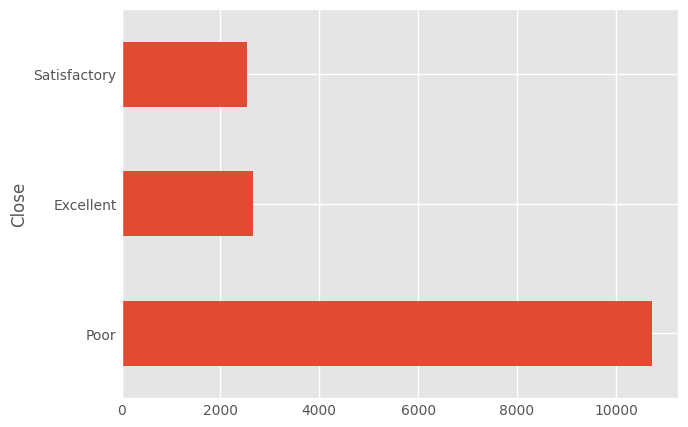

In [51]:
def rank_performance(stock_price):
    if stock_price <= 50:
        return "Poor"
    elif stock_price > 50 and stock_price <= 100:
        return "Satisfactory"
    else:
        return "Excellent"
    
ibm["Close"].apply(rank_performance).value_counts().plot(kind="barh")

In [54]:
average_stock_price = ibm["Close"].mean()

<Axes: ylabel='count'>

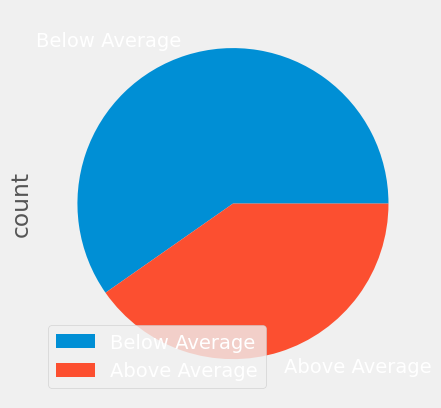

In [64]:
def rank_performance(stock_price):
    if stock_price >= average_stock_price:
        return "Above Average"
    return "Below Average"

plt.style.use("fivethirtyeight")

ibm["Close"].apply(rank_performance).value_counts().plot(kind="pie", legend=True)

In [1]:
import matplotlib

In [3]:
pip install seaborn


   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   ---- ---------------------------------- 30.7/294.9 kB 435.7 kB/s eta 0:00:01
   -------- ------------------------------ 61.4/294.9 kB 469.7 kB/s eta 0:00:01
   -------------- ----------------------- 112.6/294.9 kB 731.4 kB/s eta 0:00:01
   ------------------------------- -------- 235.5/294.9 kB 1.2 MB/s eta 0:00:01
   ------------------------------- -------- 235.5/294.9 kB 1.2 MB/s eta 0:00:01
   -------------------------------------- - 286.7/294.9 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 1.0 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 25.1
[notice] To update, run: C:\Users\johan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd # libreria manipulacion de datos
import seaborn as sns # Libreria graficas
import numpy as np

%matplotlib inline


In [5]:
anscombe = pd.read_csv('https://github.com/mwaskom/seaborn-data/raw/master/anscombe.csv')
anscombe


,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33
5,I,14.0,9.96
6,I,6.0,7.24
7,I,4.0,4.26
8,I,12.0,10.84
9,I,7.0,4.82


In [6]:
# calcular los valores de la media y la varianza de cada dataset
agg = anscombe.groupby('dataset').agg([np.mean, np.var])
agg


C:\Users\johan\AppData\Local\Temp\ipykernel_20396\538590240.py:2: FutureWarning: The provided callable <function mean at 0x000001A97FE15120> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg = anscombe.groupby('dataset').agg([np.mean, np.var])
C:\Users\johan\AppData\Local\Temp\ipykernel_20396\538590240.py:2: FutureWarning: The provided callable <function var at 0x000001A97FE153A0> is currently using SeriesGroupBy.var. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "var" instead.
  agg = anscombe.groupby('dataset').agg([np.mean, np.var])
C:\Users\johan\AppData\Local\Temp\ipykernel_20396\538590240.py:2: FutureWarning: The provided callable <function mean at 0x000001A97FE15120> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To 

x               y          
        mean   var      mean       var
dataset                               
I        9.0  11.0  7.500909  4.127269
II       9.0  11.0  7.500909  4.127629
III      9.0  11.0  7.500000  4.122620
IV       9.0  11.0  7.500909  4.123249

In [10]:
anscombe = sns.load_dataset('anscombe')

In [12]:
corr = [g[['x', 'y']].corr().loc['x', 'y'] for _, g in anscombe.groupby('dataset')]

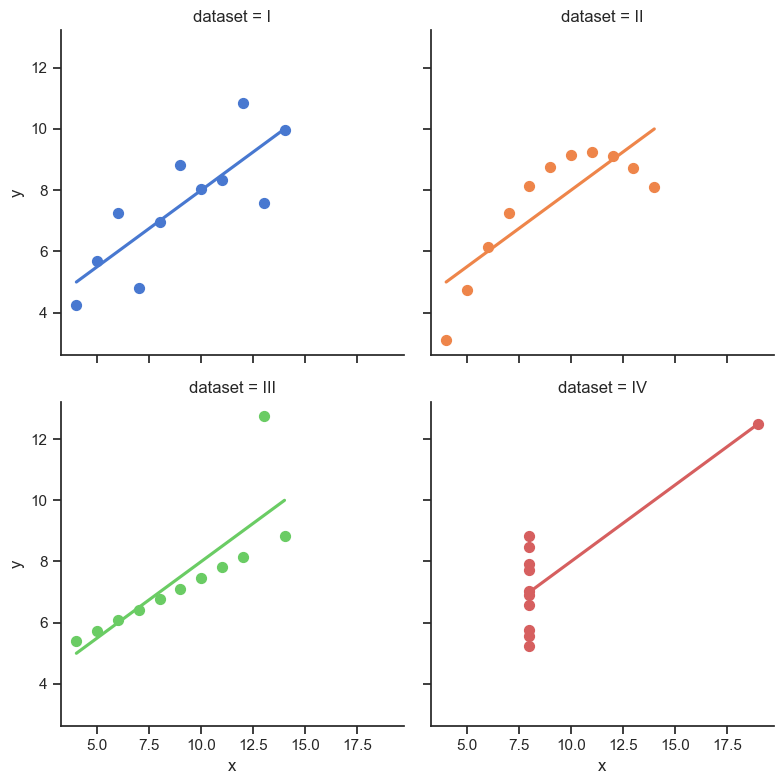

In [14]:
# Grafica Usando seaborn
sns.set(style="ticks")
sns.lmplot(x="x", y="y", col="dataset", hue="dataset", data=anscombe,
               col_wrap=2, ci=None, palette="muted", height=4,
               scatter_kws={"s": 50, "alpha": 1});


In [16]:
# calculo de los valores de la regresion lineal
fits = [np.polyfit(g['x'], g['y'], 1) for _, g in anscombe.groupby('dataset')]


In [17]:
# Almacenar los valores calculados de las regresiones lineales en un dataframe
val_reg = pd.DataFrame(fits,columns=['pendiente','intercepto'],index='I II II IV'.split())
val_reg.index.names = ['dataset']
val_reg


,pendiente,intercepto
dataset,,
I,0.500091,3.000091
II,0.500000,3.000909
II,0.499727,3.002455
IV,0.499909,3.001727


In [18]:
# La mayoria de los datos son inventados para evitar los warnings por divisiones por cero
# o valores igual a infinito, entonces apagare los warnings
import warnings; warnings.simplefilter('ignore')


In [19]:
import numpy as np
x = np.linspace(0,5, 11)
y = x ** 2


In [21]:
import matplotlib.pyplot as plt


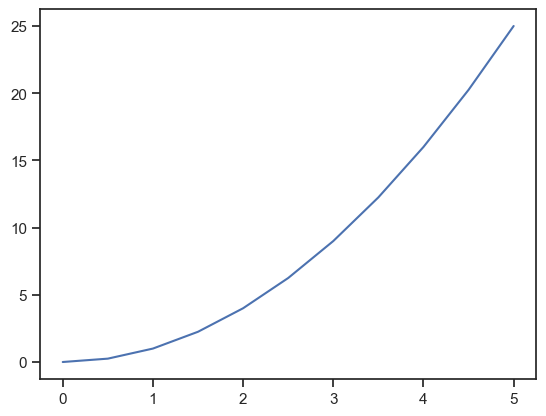

In [22]:
# método basico para graficar X vs Y
plt.plot(x, y) # se grafica una linea de color azul

plt.show() # Mostrar la grafica luego de que ya se definio todos los elementos
# plt.show() no es necesario en jupyter notebook



In [23]:
import numpy as np
x = np.linspace(0,5, 11)
y = x ** 2


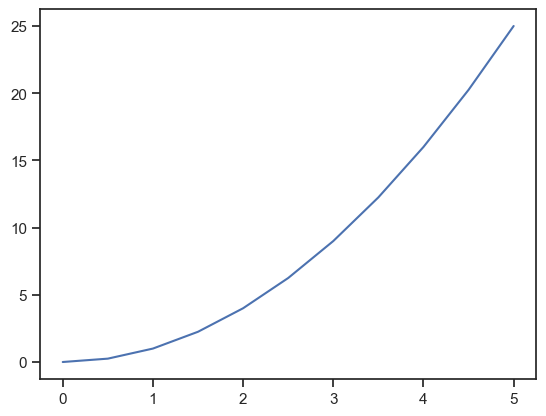

In [24]:
# método basico para graficar X vs Y
plt.plot(x, y) # se grafica una linea de color azul

plt.show() # Mostrar la grafica luego de que ya se definio todos los elementos
# plt.show() no es necesario en jupyter notebook


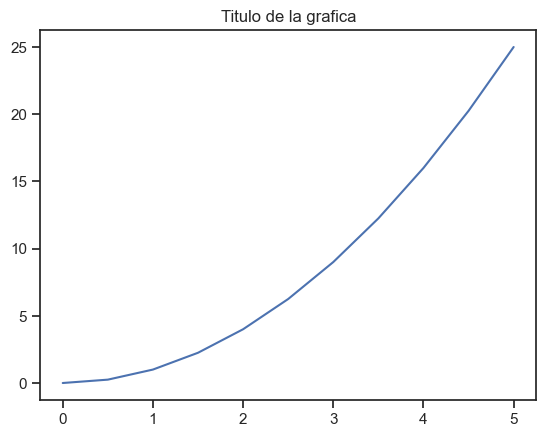

In [25]:
plt.plot(x, y) # se grafica una linea de color azul
plt.title('Titulo de la grafica'); # definir el titulo de la grafica


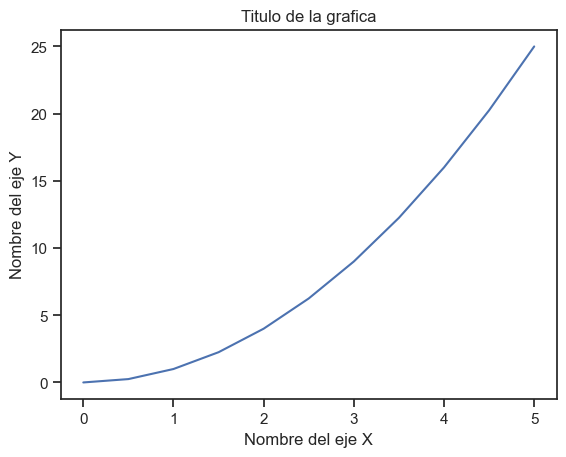

In [26]:
plt.plot(x, y) # se grafica una linea de color azul
plt.xlabel('Nombre del eje X') # definir el nombre del eje X
plt.ylabel('Nombre del eje Y') # definir el nombre del eje Y
plt.title('Titulo de la grafica'); # definir el titulo de la grafica


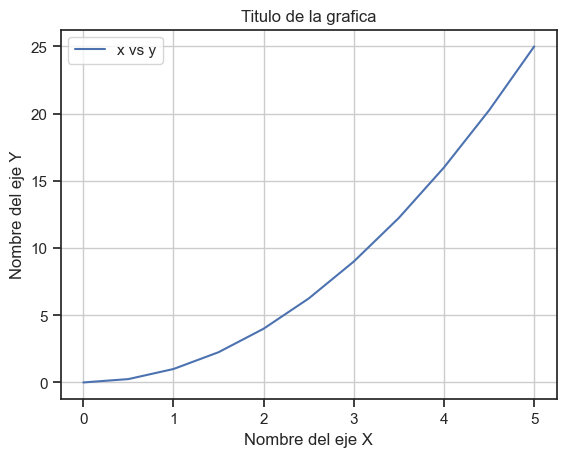

In [28]:
plt.plot(x, y, label="x vs y") # se grafica una linea de color azul
# se pone en el atributo 'label' el textto deseado

plt.xlabel('Nombre del eje X') # definir el nombre del eje X
plt.ylabel('Nombre del eje Y') # definir el nombre del eje Y
plt.title('Titulo de la grafica') # definir el titulo de la grafica
plt.legend() # agregar el legend al plot

plt.grid(True) # poner grid en la grafica


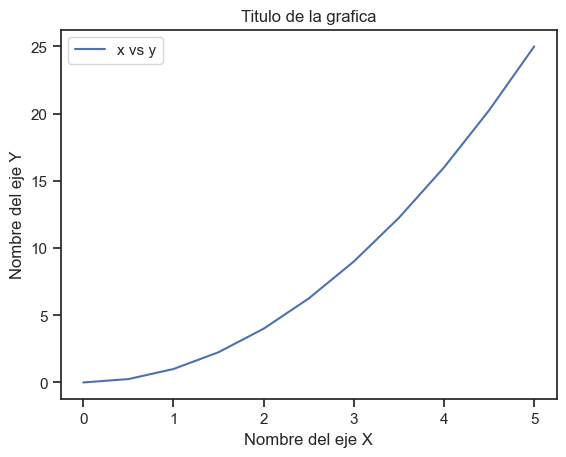

In [27]:
plt.plot(x, y, label="x vs y") # se grafica una linea de color azul
# se pone en el atributo 'label' el textto deseado

plt.xlabel('Nombre del eje X') # definir el nombre del eje X
plt.ylabel('Nombre del eje Y') # definir el nombre del eje Y
plt.title('Titulo de la grafica') # definir el titulo de la grafica
plt.legend(); # agregar el legend al plot


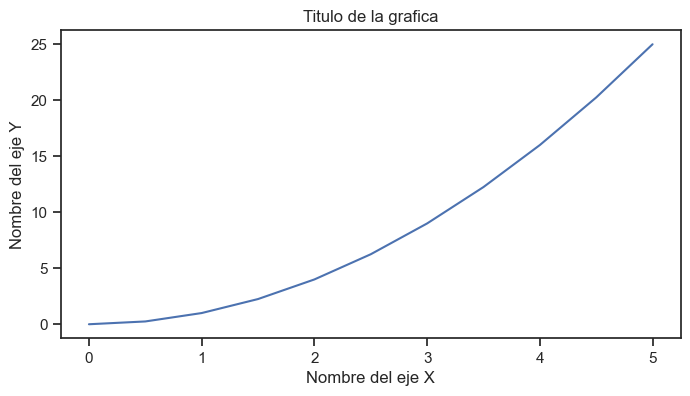

In [29]:
# se cambia el tamaño de la figura y el numero de puntos por pulgada
plt.figure(figsize=(8,4), dpi=100)

plt.plot(x, y) # se grafica una linea de color azul

plt.xlabel('Nombre del eje X') # definir el nombre del eje X
plt.ylabel('Nombre del eje Y') # definir el nombre del eje Y
plt.title('Titulo de la grafica'); # definir el titulo de la grafica

# agrego ; al final del ultimo comando para solo mostrar la grafica
# plt.show() no es necesario en jupyter notebook


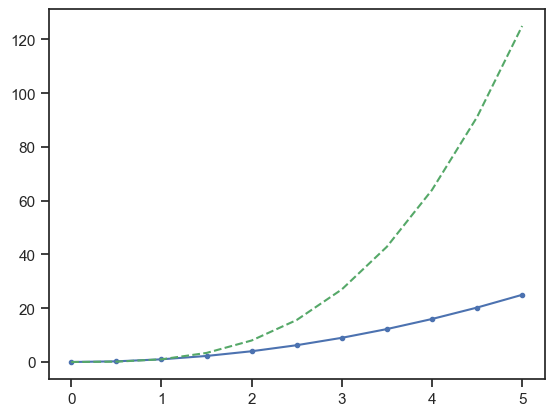

In [30]:
# Estilo MATLAB de estilo y color de linea
plt.plot(x, x**2, 'b.-') # linea azul con puntos
plt.plot(x, x**3, 'g--'); # Linea verde discontinua


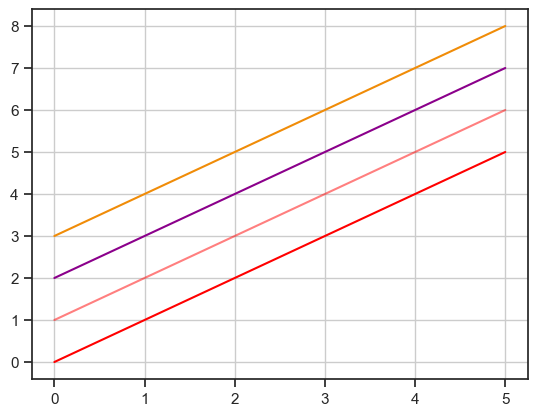

In [31]:
plt.plot(x, x, color="red") # Medio transparente
plt.plot(x, x+1, color="red", alpha=0.5) # Medio transparente
plt.plot(x, x+2, color="#8B008B")        # RGB hex code
plt.plot(x, x+3, color="#F08C08");       # RGB hex code
plt.grid(True) # poner grid en la grafica


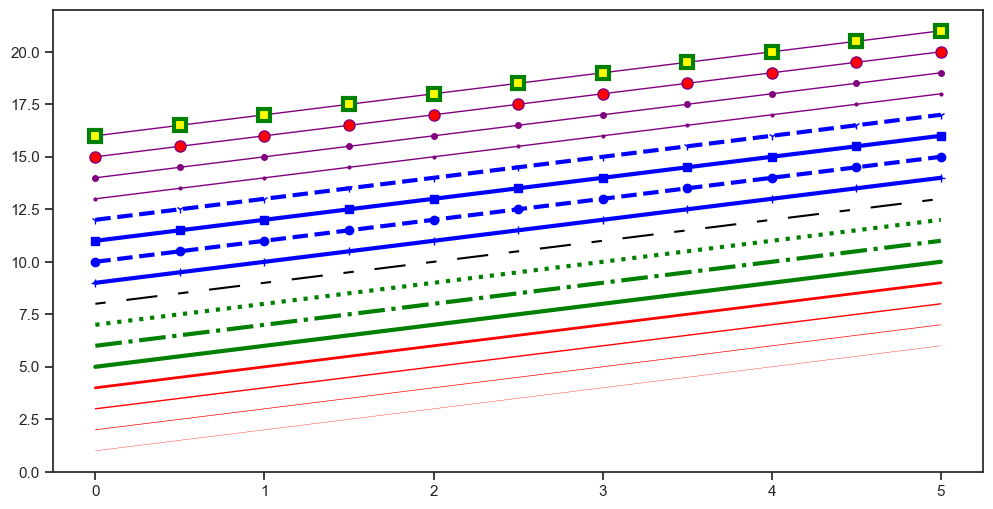

In [32]:
plt.subplots(figsize=(12,6))

plt.plot(x, x+1, color="red", linewidth=0.25)
plt.plot(x, x+2, color="red", linewidth=0.50)
plt.plot(x, x+3, color="red", linewidth=1.00)
plt.plot(x, x+4, color="red", linewidth=2.00)

# posibles opciones linestype ‘-‘, ‘–’, ‘-.’, ‘:’, ‘steps’
plt.plot(x, x+5, color="green", lw=3, linestyle='-')
plt.plot(x, x+6, color="green", lw=3, ls='-.')
plt.plot(x, x+7, color="green", lw=3, ls=':')

# lineas parametrizadas
line, = plt.plot(x, x+8, color="black", lw=1.50)
line.set_dashes([5, 10, 15, 10]) # formato: longitud de linea, longitud de espacio, ...

# posibles simbolos del marcas: marker = '+', 'o', '*', 's', ',', '.',bb '1', '2', '3', '4', ...
plt.plot(x, x+ 9, color="blue", lw=3, ls='-', marker='+')
plt.plot(x, x+10, color="blue", lw=3, ls='--', marker='o')
plt.plot(x, x+11, color="blue", lw=3, ls='-', marker='s')
plt.plot(x, x+12, color="blue", lw=3, ls='--', marker='1')

# tamaño y color de la marca
plt.plot(x, x+13, color="purple", lw=1, ls='-', marker='o', markersize=2)
plt.plot(x, x+14, color="purple", lw=1, ls='-', marker='o', markersize=4)
plt.plot(x, x+15, color="purple", lw=1, ls='-', marker='o', markersize=8, markerfacecolor="red")
plt.plot(x, x+16, color="purple", lw=1, ls='-', marker='s', markersize=8,
        markerfacecolor="yellow", markeredgewidth=3, markeredgecolor="green");


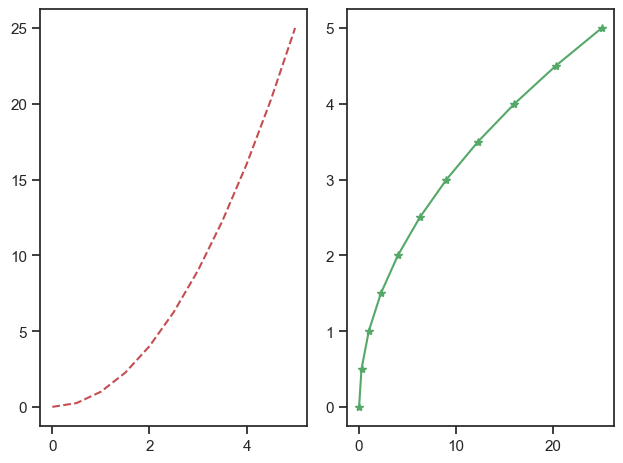

In [33]:
# la función es plt.subplot(nrows, ncols, plot_number)

plt.subplot(1,2,1) # subplot fila=1 Col=2, grafica=1
plt.plot(x, y, 'r--') # r-- color rojo y linea discontinua
plt.subplot(1,2,2) # subplot fila=1 Col=2, grafica=2
plt.plot(y, x, 'g*-'); # para no mostrar info de la función
plt.tight_layout() # para que no se superpongan las graficas


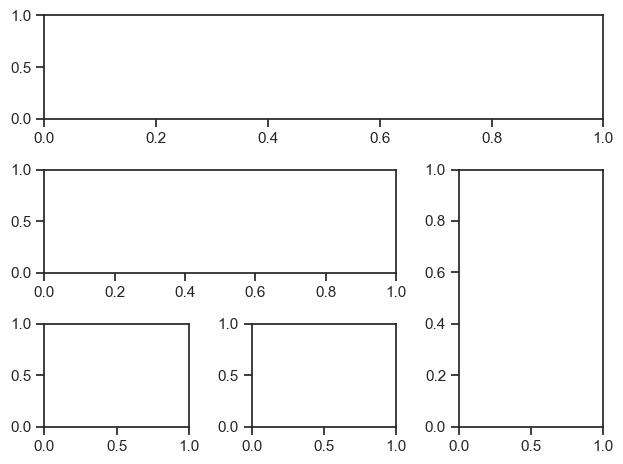

In [34]:
plt.subplot2grid((3,3), (0,0), colspan=3)
plt.subplot2grid((3,3), (1,0), colspan=2)
plt.subplot2grid((3,3), (1,2), rowspan=2)
plt.subplot2grid((3,3), (2,0))
plt.subplot2grid((3,3), (2,1))
plt.tight_layout() # para que no se superpongan las graficas


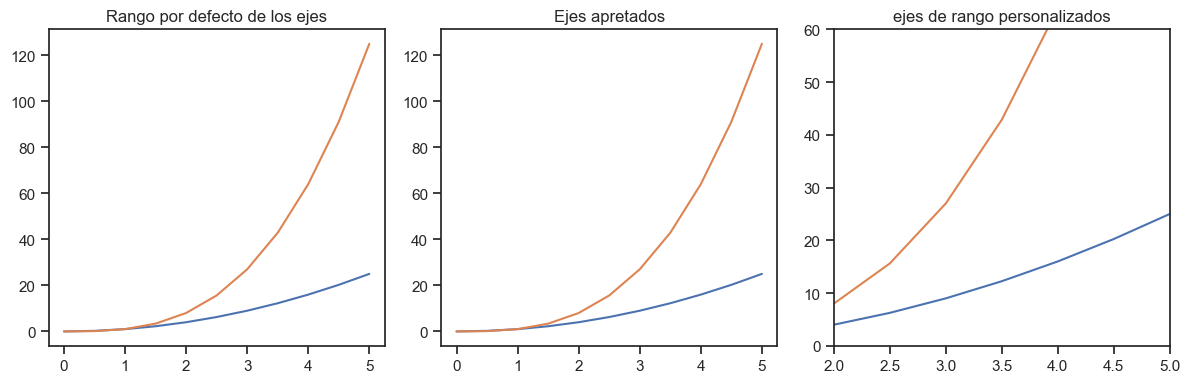

In [35]:
plt.figure(figsize=(12, 4))

plt.subplot(1,3,1)
plt.plot(x, x**2, x, x**3)
plt.title("Rango por defecto de los ejes")

plt.subplot(1,3,2)
plt.plot(x, x**2, x, x**3)
plt.axis('tight')
plt.title("Ejes apretados")

plt.subplot(1,3,3)
plt.plot(x, x**2, x, x**3)
plt.ylim([0, 60])
plt.xlim([2, 5])
plt.title("ejes de rango personalizados");

plt.tight_layout() # para que no se superpongan las graficas


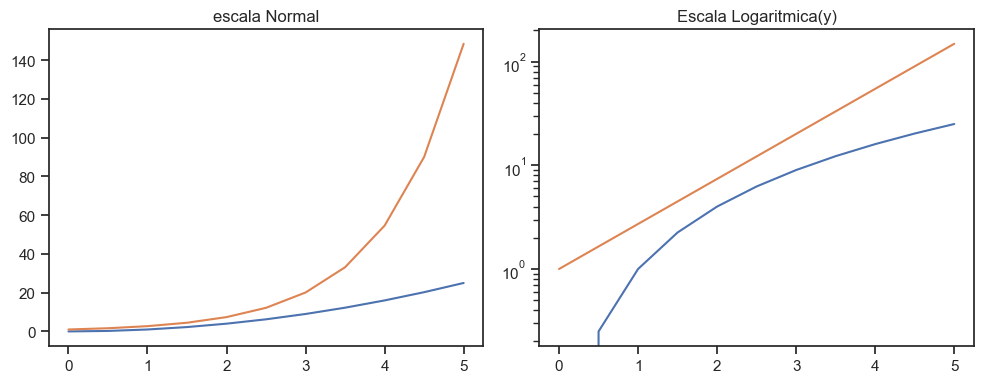

In [36]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(x, x**2, x, np.exp(x))
plt.title("escala Normal")

plt.subplot(1,2,2)
plt.plot(x, x**2, x, np.exp(x))
plt.yscale("log")
plt.title("Escala Logaritmica(y)");

plt.tight_layout() # para que no se superpongan las graficas


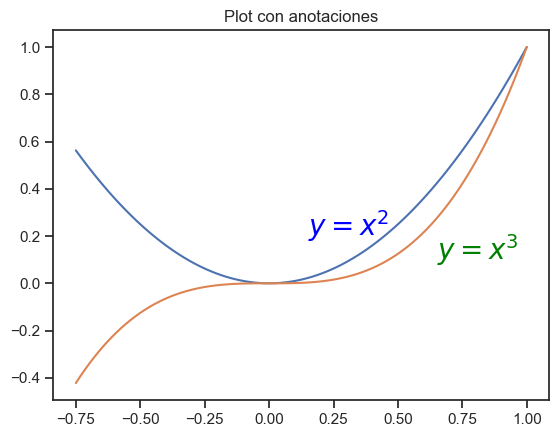

In [37]:
# Datos para graficar
xx = np.linspace(-0.75, 1., 100)

plt.plot(xx, xx**2, xx, xx**3)
plt.title("Plot con anotaciones")

# Anotacion 1
plt.text(0.15, 0.2, r"$y=x^2$", fontsize=20, color="blue")
#Anotacion 2
plt.text(0.65, 0.1, r"$y=x^3$", fontsize=20, color="green");


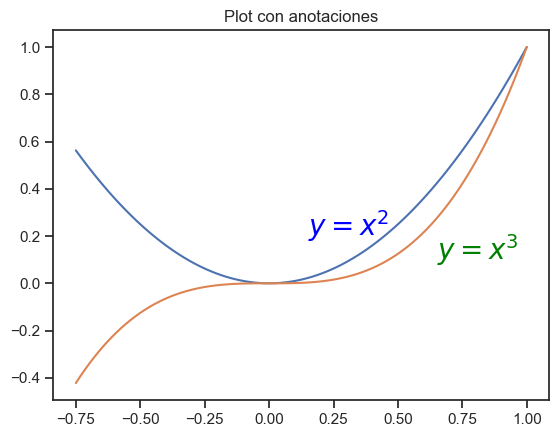

In [38]:
# Datos para graficar
xx = np.linspace(-0.75, 1., 100)

plt.plot(xx, xx**2, xx, xx**3)
plt.title("Plot con anotaciones")

# Anotacion 1
plt.text(0.15, 0.2, r"$y=x^2$", fontsize=20, color="blue")
#Anotacion 2
plt.text(0.65, 0.1, r"$y=x^3$", fontsize=20, color="green");


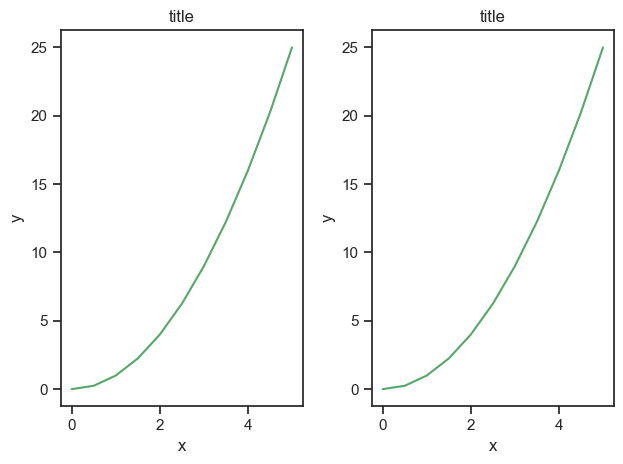

In [39]:
# Se crea una figura y 2 subplots
# cada subplt se accede por medio de los objetos axes

fig, axes = plt.subplots(nrows=1, ncols=2)

for ax in axes:
    ax.plot(x, y, 'g')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('title')
plt.tight_layout() # para que no se superpongan las graficas


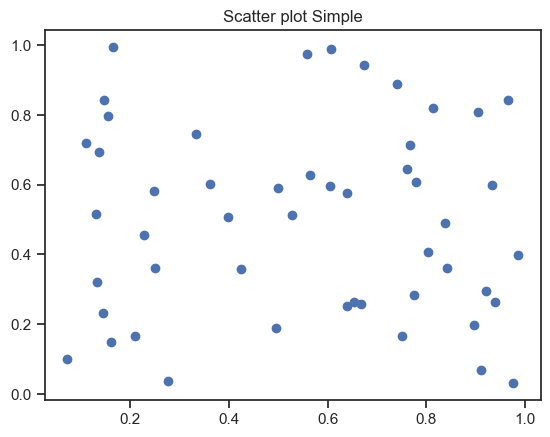

In [40]:
#Grafica X vs Y
# crear datos aleatorios
N = 50
x = np.random.rand(N)
y = np.random.rand(N)

plt.scatter(x, y)
plt.title("Scatter plot Simple");
plt.show() # En jupyter notebook no es necesario este comando


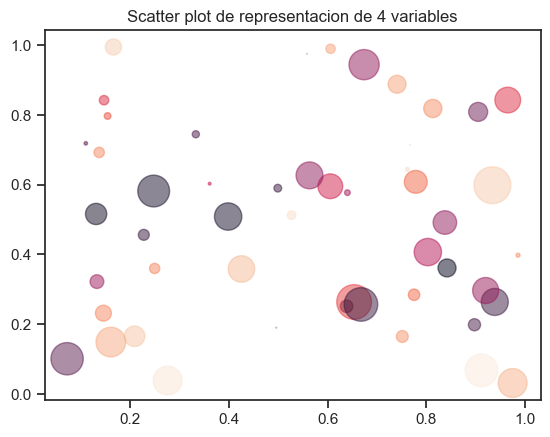

In [41]:
# se creara otra variable que se representara con colores
colors = np.random.rand(N) # usar colores aleatorios

# se creara otra variable que se representara con el area de los puntos
area = np.pi * (15 * np.random.rand(N))**2  # 0 to 15 point radio

plt.scatter(x, y, s=area, c=colors, alpha=0.5) # el atributo alpha es para la transparencia
plt.title("Scatter plot de representacion de 4 variables");


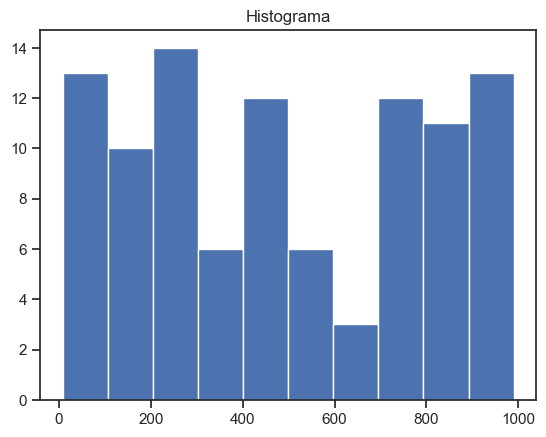

In [42]:
# crear datos aleatorios
from random import sample
data = sample(range(1, 1000), 100)

plt.hist(data,bins = 10) # bins el numero de divisiones del histograma
plt.title("Histograma");


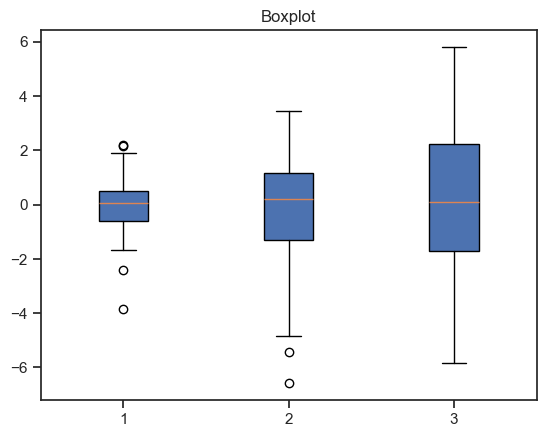

In [43]:
#crear datos aleatorios
data = [np.random.normal(0, std, 100) for std in range(1, 4)]

# boxplot rectangular
plt.boxplot(data,vert=True,patch_artist=True);
plt.title("Boxplot");


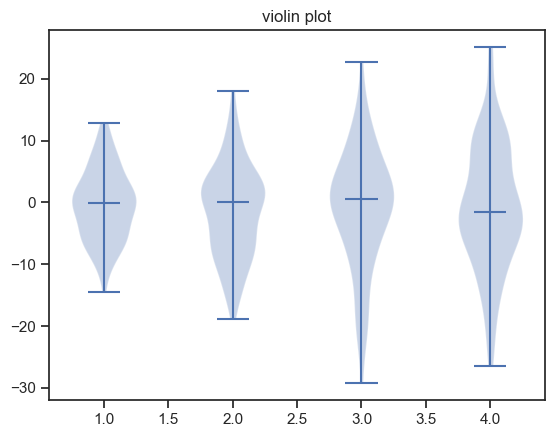

In [44]:
all_data = [np.random.normal(0, std, 100) for std in range(6, 10)]

# grafico de violin, se puede activar la visualizacion de la media y de la mediana
plt.violinplot(all_data, showmeans=False, showmedians=True)
plt.title('violin plot');


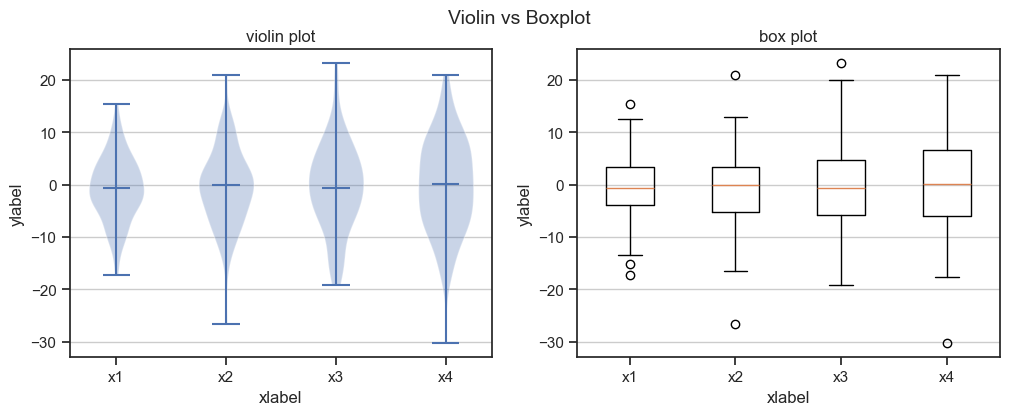

In [45]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# generar datos aleatorios
all_data = [np.random.normal(0, std, 100) for std in range(6, 10)]

# plot de violin
axes[0].violinplot(all_data,
                   showmeans=False,
                   showmedians=True)
axes[0].set_title('violin plot')

# plot box plot
axes[1].boxplot(all_data)
axes[1].set_title('box plot')

# agregando lineas horizontales
for ax in axes:
    ax.yaxis.grid(True)
    ax.set_xticks([y+1 for y in range(len(all_data))])
    ax.set_xlabel('xlabel')
    ax.set_ylabel('ylabel')

# agragando los nombres a las divisiones del eje x (x-tick labels)
plt.setp(axes, xticks=[y+1 for y in range(len(all_data))],
         xticklabels=['x1', 'x2', 'x3', 'x4'])

fig.suptitle("Violin vs Boxplot",fontsize = 14) # titulo general de la grafica
plt.show()


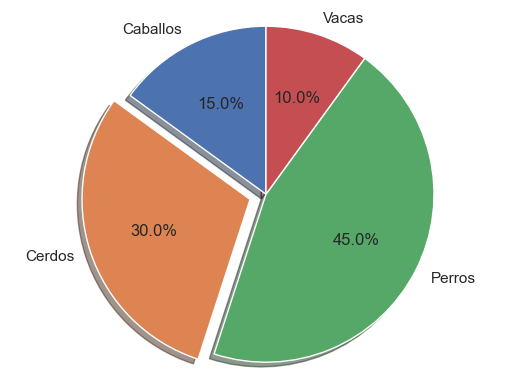

In [48]:
labels = 'Caballos', 'Cerdos', 'Perros', 'Vacas'
sizes = [15, 30, 45, 10]
explode = (0, 0.1, 0, 0)  # solo "Saque" el 2do pedazo (ejem. 'cerdos')

plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90)

plt.axis('equal')  #La relación de aspecto igual garantiza que el círculo sea homogeneo
plt.show()


In [ ]:
# guardar la figura
fig.savefig("figura.png")
fig.savefig("figura.pdf", dpi=200)


In [49]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')


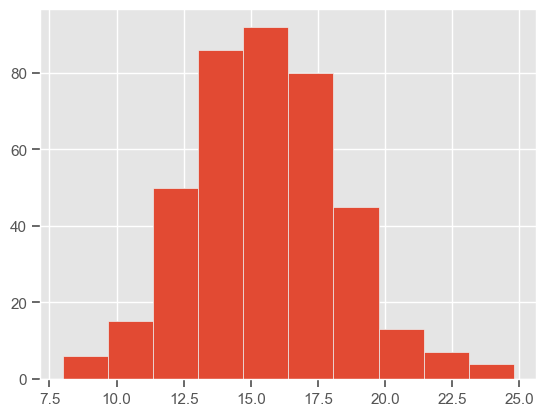

In [51]:
df1 = pd.read_csv('https://github.com/mwaskom/seaborn-data/raw/master/mpg.csv')
df1.head()

df1['acceleration'].hist();


In [52]:
df2 = pd.read_csv('https://github.com/mwaskom/seaborn-data/raw/master/iris.csv')
df2.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


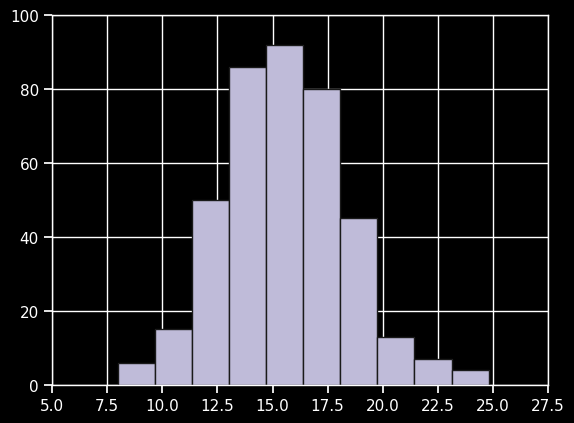

In [53]:
plt.style.use('dark_background')
df1['acceleration'].hist();

plt.style.use('fivethirtyeight')
df1['acceleration'].hist();

# El estilo por defecto es
plt.style.use('classic')
df1['acceleration'].hist();


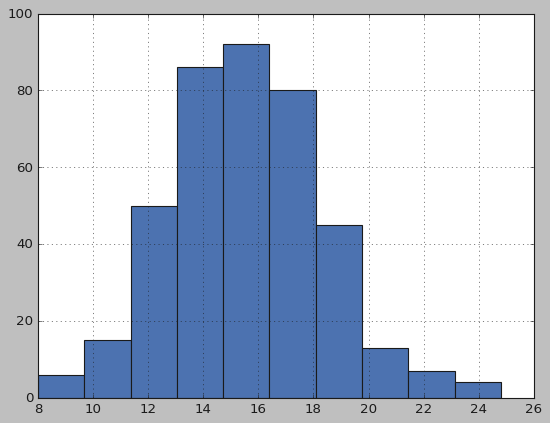

In [54]:
# El estilo por defecto es
plt.style.use('classic')
df1['acceleration'].hist();


In [55]:
# Seguire usando el estilo ggplot para ver los tipos de grafica de pandas
plt.style.use('ggplot')


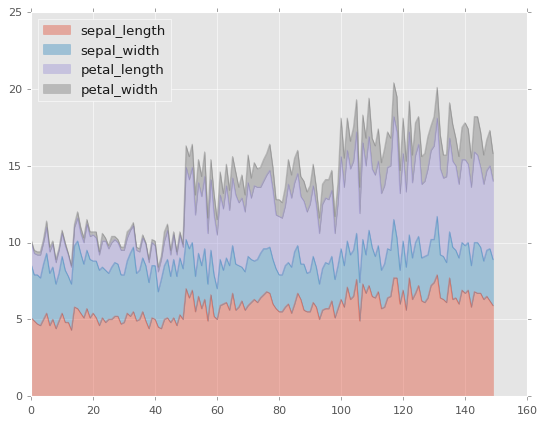

In [56]:
# Se puede hacer de las siguiente manera
#df2.plot(kind='area',alpha = 0.4)

df2.plot.area(alpha=0.4);


In [57]:
# Visualizacion de datos
df2.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


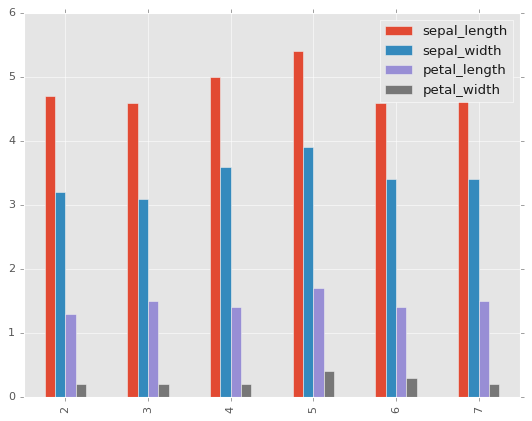

In [58]:
# los nombres de cada columna equivalen a un color diferente
# Solo se graficaran algunos datos
df2.iloc[2:8].plot.bar();


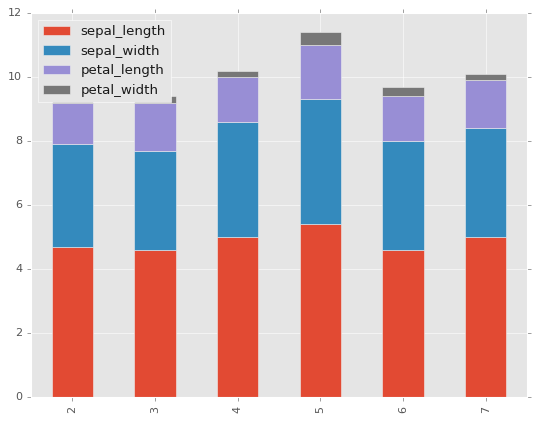

In [59]:
df2.iloc[2:8].plot.bar(stacked=True);


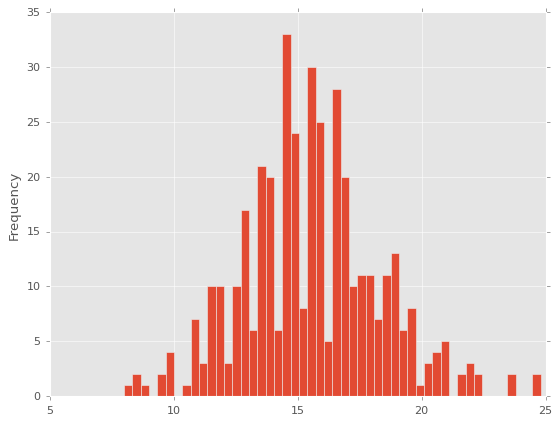

In [60]:
df1['acceleration'].plot.hist(bins=50);


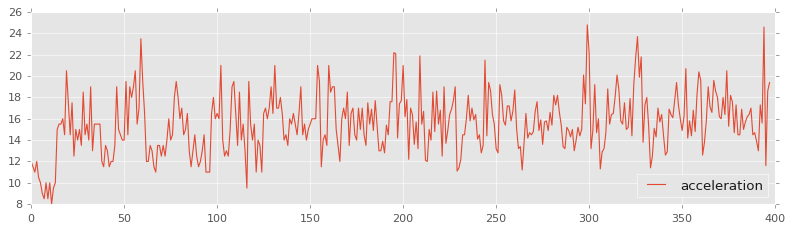

In [61]:
# eje y = valores de la acceleracion
# eje x = valores del index
# atributo lw es el grosor de la linea
df1.plot.line(y='acceleration',figsize=(12,3),lw=1);


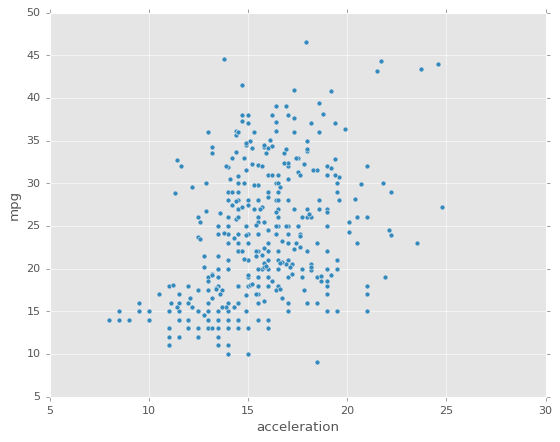

In [62]:
df1.plot.scatter(x='acceleration',y='mpg');


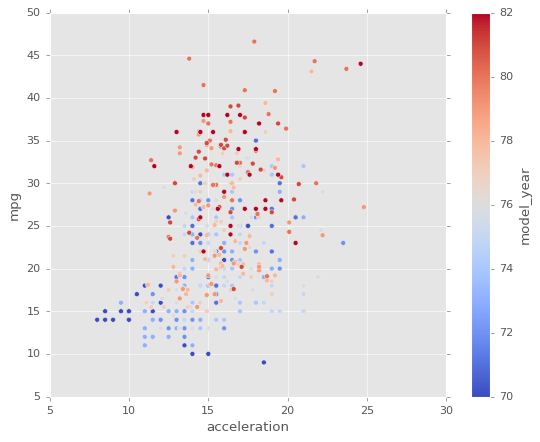

In [63]:
df1.plot.scatter(x='acceleration',y='mpg',c='model_year',cmap='coolwarm');


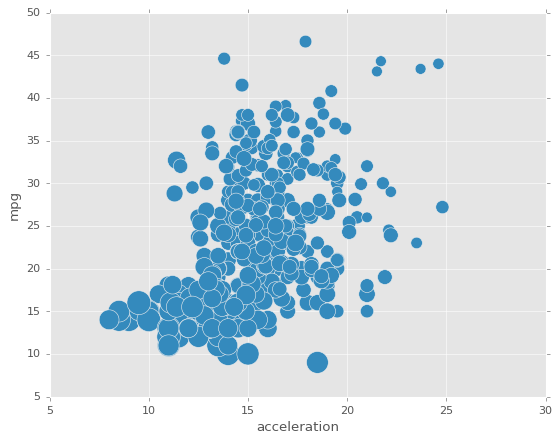

In [64]:
df1.plot.scatter(x='acceleration',y='mpg',s=df1['horsepower']*2);


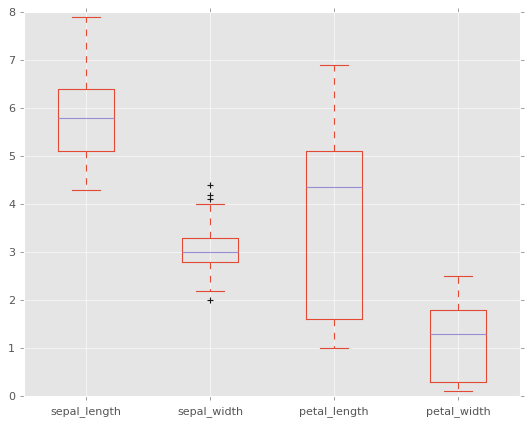

In [65]:
df2.plot.box(); # también se puede poner by= argumento para groupby


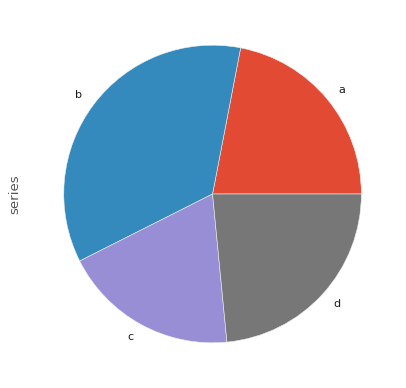

In [66]:
serie = pd.Series(3 * np.random.rand(4), index=['a', 'b', 'c', 'd'], name='series')
serie.plot.pie(figsize=(6, 6));


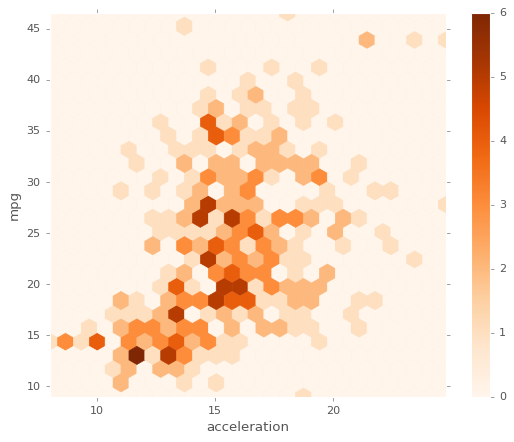

In [67]:
df1.plot.hexbin(x='acceleration',y='mpg',gridsize=25,cmap='Oranges');


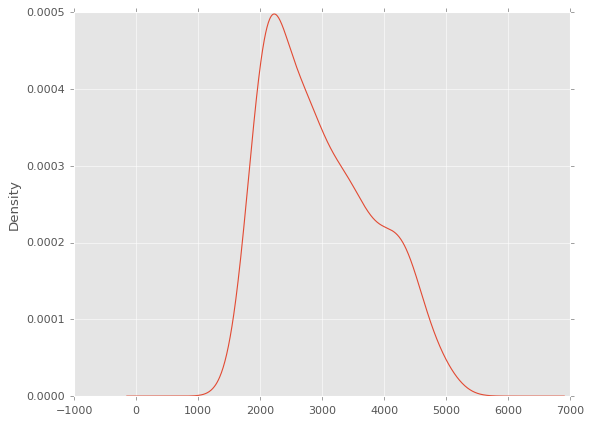

In [68]:
df1['weight'].plot.kde();


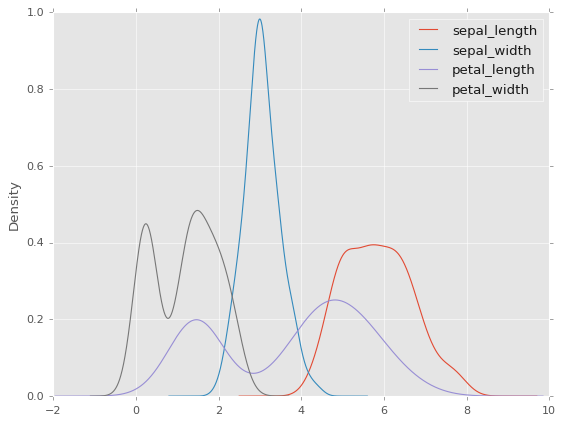

In [69]:
df2.plot.density();


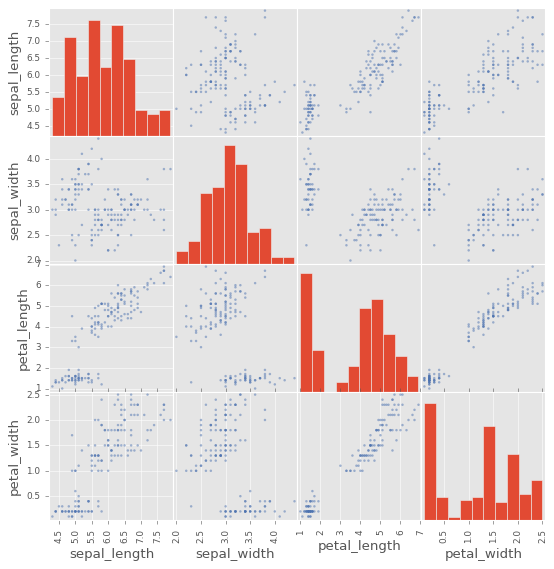

In [70]:
pd.plotting.scatter_matrix(df2, figsize=(8, 8));


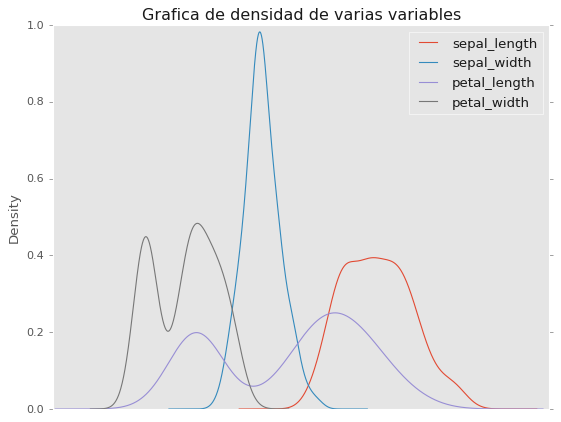

In [71]:
df2.plot.density() # grafico de densidad con pandas

plt.title('Grafica de densidad de varias variables')
plt.grid(False)
plt.xticks([]);# Para eliminar los números del eje


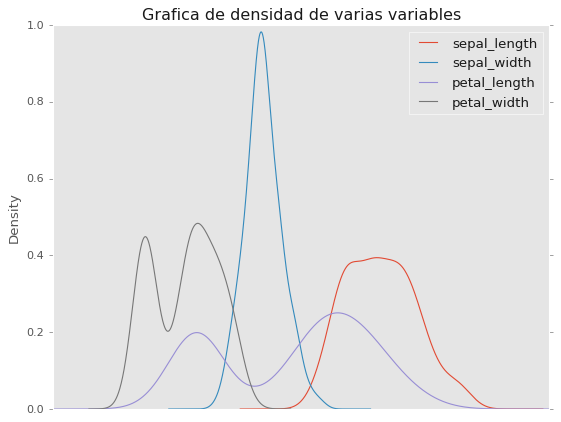

In [72]:
# La misma grafica pero adicionando los parametros en los argumentos
df2.plot.density(title='Grafica de densidad de varias variables',
                 grid=False,
                xticks = []);


In [ ]:
Referencias
http://www.matplotlib.org
http://matplotlib.org/gallery.html - Una gran galería que muestra varios tipos de graficos matplotlib. ¡Muy recomendable!
Matplotlib cheat sheet
http://www.loria.fr/~rougier/teaching/matplotlib - Un Buen tutorial de matplotlib.
https://lectures.scientific-python.org/intro/matplotlib/index.html - Otra buena referencia para matplotlib reference.
https://medium.com/plotly/introducing-plotly-express-808df010143d
https://plot.ly/python/plotly-express/
http://seaborn.pydata.org/ - Documentacion Seaborn otra libreria de graficas estadisticas
http://matplotlib.org/api/markers_api.html - documentacion de marcadores
Lista de colormaps https://matplotlib.org/stable/gallery/color/colormap_reference.html